# 07 — Statistical Analysis and Hypothesis Testing

## Objective

This notebook extends the exploratory data analysis by statistically examining relationships and differences within the leadership and management book dataset.

The analysis focuses on questions that are supported by the available data rather than selecting statistical tests solely for demonstration purposes.

The objectives are to:

1. assess the statistical characteristics of numerical variables
2. evaluate relationships between ratings and reader-engagement measures
3. examine whether engagement differs across meaningful groups where sufficient data are available
4. distinguish statistical significance from practical interpretation
5. identify findings that may inform later feature engineering and recommendation modelling

Statistical tests are applied only to variables with adequate observations and appropriate measurement characteristics.

A significance level of **α = 0.05** is used where formal hypothesis tests are conducted.

In [13]:
# ============================================================
# IMPORTS AND DATA PATHS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/jannoelvero/Documents/Ironhack/Week_11/"
    "Leadership_Management_Book_Recommendation_System"
)

DATA_FINAL = PROJECT_ROOT / "data" / "final"

books_path = DATA_FINAL / "books_master.csv"
editions_path = DATA_FINAL / "leadershipnow_editions.csv"
openlibrary_path = DATA_FINAL / "openlibrary_integrated.csv"


# ------------------------------------------------------------
# Path validation
# ------------------------------------------------------------

print("FILE PATH VALIDATION")
print("=" * 70)

print("books_master.csv:", books_path.exists())
print("leadershipnow_editions.csv:", editions_path.exists())
print("openlibrary_integrated.csv:", openlibrary_path.exists())

FILE PATH VALIDATION
books_master.csv: True
leadershipnow_editions.csv: True
openlibrary_integrated.csv: True


In [14]:
# ============================================================
# LOAD DATA
# ============================================================

books = pd.read_csv(books_path)
editions = pd.read_csv(editions_path)
openlibrary = pd.read_csv(openlibrary_path)


print("DATASET SHAPES")
print("=" * 70)

print(f"Books:        {books.shape}")
print(f"Editions:     {editions.shape}")
print(f"Open Library: {openlibrary.shape}")


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(books) == 2067
assert books["book_id"].nunique() == 2067

assert len(editions) == 1120
assert editions["book_id"].nunique() == 1120

assert len(openlibrary) == 950


print("\n✓ DATASETS LOADED AND VALIDATED")

DATASET SHAPES
Books:        (2067, 18)
Editions:     (1120, 23)
Open Library: (950, 50)

✓ DATASETS LOADED AND VALIDATED


## 1. Statistical Readiness Assessment

Before formulating inferential hypotheses, numerical variables are evaluated for sample size, missingness, central tendency, variability, skewness, and observed range.

This prevents inappropriate statistical testing of variables with insufficient coverage or unsuitable distributional characteristics.

Reader-engagement variables are expected to be strongly right-skewed based on the preceding exploratory analysis. Therefore, both parametric and non-parametric approaches will be considered where appropriate.

In [15]:
# ============================================================
# STATISTICAL READINESS AUDIT
# ============================================================

numeric_variables = [
    "first_publish_year",
    "publication_year_observed",
    "average_rating",
    "ratings_count",
    "edition_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count"
]


readiness_rows = []

for col in numeric_variables:

    data = pd.to_numeric(
        books[col],
        errors="coerce"
    ).dropna()

    readiness_rows.append({
        "variable": col,
        "available_n": len(data),
        "missing_n": books[col].isna().sum(),
        "coverage_pct": len(data) / len(books) * 100,
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
        "skewness": data.skew()
    })


readiness = pd.DataFrame(readiness_rows)


display(
    readiness.style.format({
        "coverage_pct": "{:.2f}%",
        "mean": "{:,.2f}",
        "median": "{:,.2f}",
        "std": "{:,.2f}",
        "min": "{:,.2f}",
        "max": "{:,.2f}",
        "skewness": "{:.2f}"
    })
)

,variable,available_n,missing_n,coverage_pct,mean,median,std,min,max,skewness
0,first_publish_year,947,1120,45.82%,"2,000.98","2,004.00",16.09,"1,900.00","2,025.00",-1.58
1,publication_year_observed,1117,950,54.04%,"2,023.44","2,023.00",1.10,"2,022.00","2,025.00",0.07
2,average_rating,282,1785,13.64%,3.88,4.27,1.41,0.00,5.00,-1.47
3,ratings_count,282,1785,13.64%,4.62,1.50,17.72,0.00,278.00,13.49
4,edition_count,950,1117,45.96%,7.28,4.00,9.86,1.00,95.00,3.96
5,want_to_read_count,807,1260,39.04%,47.49,9.00,266.80,0.00,"6,754.00",20.85
6,currently_reading_count,807,1260,39.04%,3.93,1.00,24.90,0.00,643.00,21.88
7,already_read_count,807,1260,39.04%,2.31,0.00,14.05,0.00,328.00,17.87


In [16]:
# ============================================================
# PAIRWISE SAMPLE-SIZE AUDIT
# ============================================================

analysis_variables = [
    "average_rating",
    "ratings_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count",
    "edition_count",
    "first_publish_year"
]


pairwise_n = pd.DataFrame(
    index=analysis_variables,
    columns=analysis_variables,
    dtype=int
)


for col1 in analysis_variables:

    for col2 in analysis_variables:

        pairwise_n.loc[col1, col2] = (
            books[[col1, col2]]
            .dropna()
            .shape[0]
        )


pairwise_n = pairwise_n.astype(int)

print("PAIRWISE COMPLETE OBSERVATIONS")
print("=" * 80)

display(pairwise_n)

PAIRWISE COMPLETE OBSERVATIONS


,average_rating,ratings_count,want_to_read_count,currently_reading_count,already_read_count,edition_count,first_publish_year
average_rating,282,282,282,282,282,282,281
ratings_count,282,282,282,282,282,282,281
want_to_read_count,282,282,807,807,807,807,805
currently_reading_count,282,282,807,807,807,807,805
already_read_count,282,282,807,807,807,807,805
edition_count,282,282,807,807,807,950,947
first_publish_year,281,281,805,805,805,947,947


In [17]:
# ============================================================
# DISTRIBUTION / NORMALITY DIAGNOSTIC
# ============================================================

normality_variables = [
    "average_rating",
    "ratings_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count",
    "edition_count"
]


normality_results = []


for col in normality_variables:

    data = pd.to_numeric(
        books[col],
        errors="coerce"
    ).dropna()

    # Shapiro-Wilk is appropriate here because
    # all current samples are below 5,000 observations.
    shapiro_stat, shapiro_p = stats.shapiro(data)

    normality_results.append({
        "variable": col,
        "n": len(data),
        "skewness": data.skew(),
        "shapiro_W": shapiro_stat,
        "shapiro_p": shapiro_p,
        "normal_at_0.05": shapiro_p > 0.05
    })


normality_results = pd.DataFrame(normality_results)


display(
    normality_results.style.format({
        "skewness": "{:.3f}",
        "shapiro_W": "{:.4f}",
        "shapiro_p": "{:.6g}"
    })
)

,variable,n,skewness,shapiro_W,shapiro_p,normal_at_0.05
0,average_rating,282,-1.472,0.7718,1.60361e-19,False
1,ratings_count,282,13.485,0.1661,1.90047e-33,False
2,want_to_read_count,807,20.845,0.1152,1.87708e-51,False
3,currently_reading_count,807,21.878,0.1033,1.14718e-51,False
4,already_read_count,807,17.867,0.1217,2.47173e-51,False
5,edition_count,950,3.956,0.6019,4.54455e-42,False


### Statistical Readiness Interpretation

The statistical readiness assessment confirms substantial differences in variable coverage and distributional characteristics.

Publication variables have the strongest numerical coverage, with 947 observations for `first_publish_year` and 1,117 for `publication_year_observed`. Reader-engagement measures are available for 807 books, while average ratings and rating counts are available for only 282 books.

All tested numerical variables significantly depart from normality according to the Shapiro-Wilk test at α = 0.05. The strongest departures occur among reader-engagement variables, which also exhibit extreme positive skewness. For example, `want_to_read_count`, `currently_reading_count`, and `already_read_count` have skewness values of 20.85, 21.88, and 17.87 respectively.

The pairwise-completeness assessment shows that the three reader-engagement variables have 807 joint observations. Rating-based analyses have 282 observations, while relationships involving first publication year and engagement retain approximately 805 observations.

Given these distributional characteristics, non-parametric methods are particularly appropriate for analyses involving raw engagement counts. Spearman rank correlation will therefore be preferred for monotonic relationships involving strongly skewed variables, while Pearson correlation may be reported selectively for comparison or after justified transformation.

Statistical significance will be interpreted together with effect size and practical meaning rather than relying on p-values alone.

## 2. Hypothesis 1 — Average Rating and Reader Interest

### Research Question

Is average book rating associated with reader interest as measured by the number of users who want to read the book?

### Hypotheses

**H₀ (Null Hypothesis):**  
There is no monotonic association between average rating and `want_to_read_count` in the observed sample.

**H₁ (Alternative Hypothesis):**  
There is a monotonic association between average rating and `want_to_read_count` in the observed sample.

### Statistical Test

A **Spearman rank-order correlation** is used because:

- the variables have 282 paired observations
- `want_to_read_count` is extremely right-skewed
- average rating significantly departs from normality
- Spearman correlation does not require normally distributed variables
- the research question concerns monotonic association rather than strictly linear association

The significance level is **α = 0.05**.

HYPOTHESIS 1 RESULTS
Paired observations:              282
Spearman rho:                     -0.0781
Spearman p-value:                 0.191219

Raw Pearson r:                    0.0264
Raw Pearson p-value:              0.658636

Pearson r after log1p interest:   0.2078
Log-transformed Pearson p-value:  0.000443

STATISTICAL DECISION
Fail to reject H0 at α = 0.05.
Insufficient evidence of a statistically significant monotonic association.


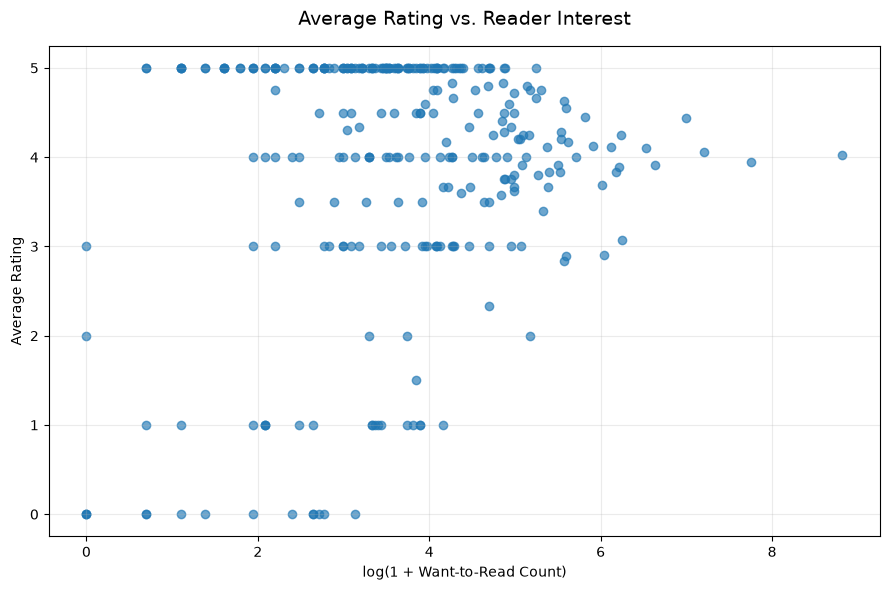

In [18]:
# ============================================================
# HYPOTHESIS 1
# Average Rating vs Want-to-Read Count
# ============================================================

h1_data = (
    books[
        [
            "book_id",
            "canonical_title",
            "average_rating",
            "want_to_read_count"
        ]
    ]
    .dropna(
        subset=[
            "average_rating",
            "want_to_read_count"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Spearman correlation
# ------------------------------------------------------------

rho, p_value = stats.spearmanr(
    h1_data["average_rating"],
    h1_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Pearson for descriptive comparison
# ------------------------------------------------------------

pearson_r, pearson_p = stats.pearsonr(
    h1_data["average_rating"],
    h1_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Log-transformed reader interest
# ------------------------------------------------------------

h1_data["log_want_to_read"] = np.log1p(
    h1_data["want_to_read_count"]
)

log_pearson_r, log_pearson_p = stats.pearsonr(
    h1_data["average_rating"],
    h1_data["log_want_to_read"]
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

alpha = 0.05

print("HYPOTHESIS 1 RESULTS")
print("=" * 75)

print(f"Paired observations:              {len(h1_data):,}")
print(f"Spearman rho:                     {rho:.4f}")
print(f"Spearman p-value:                 {p_value:.6f}")
print()
print(f"Raw Pearson r:                    {pearson_r:.4f}")
print(f"Raw Pearson p-value:              {pearson_p:.6f}")
print()
print(f"Pearson r after log1p interest:   {log_pearson_r:.4f}")
print(f"Log-transformed Pearson p-value:  {log_pearson_p:.6f}")

print("\nSTATISTICAL DECISION")
print("=" * 75)

if p_value < alpha:
    print("Reject H0 at α = 0.05.")
    print(
        "Evidence indicates a statistically significant "
        "monotonic association."
    )
else:
    print("Fail to reject H0 at α = 0.05.")
    print(
        "Insufficient evidence of a statistically significant "
        "monotonic association."
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    h1_data["log_want_to_read"],
    h1_data["average_rating"],
    alpha=0.65
)

ax.set_title(
    "Average Rating vs. Reader Interest",
    fontsize=14,
    pad=15
)

ax.set_xlabel("log(1 + Want-to-Read Count)")
ax.set_ylabel("Average Rating")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Hypothesis 1 Interpretation

The primary Spearman rank-order correlation found a small negative association between average rating and reader interest (`ρ = -0.0781`), but this relationship was **not statistically significant** (`p = 0.1912`).

At the 5% significance level, the null hypothesis is therefore **not rejected**. The observed sample does not provide sufficient evidence of a monotonic relationship between average book rating and the number of users who want to read the book.

The raw Pearson correlation similarly indicates essentially no linear relationship (`r = 0.0264`, `p = 0.6586`).

After applying a `log1p()` transformation to `want_to_read_count`, the Pearson correlation increased to `r = 0.2078` and was statistically significant (`p = 0.000443`). This suggests a weak positive linear relationship after reducing the influence of the extremely skewed reader-interest distribution.

However, the log-transformed Pearson result is treated as a supplementary sensitivity analysis rather than replacing the pre-specified Spearman hypothesis test. The different results demonstrate that the observed association is sensitive to the distributional treatment of reader-interest counts.

### Practical and Recommendation-System Implication

The results do not support treating average rating as a proxy for reader interest. A highly rated book is not necessarily a book that attracts greater reading interest, and a highly sought-after book is not necessarily more highly rated.

For recommendation modelling, **rating and reader-interest variables should therefore remain separate signals**. Rating can represent observed evaluation among users who rated a book, while `want_to_read_count` can represent a different dimension related to reader interest or popularity.

Because these variables are available for only a subset of the catalogue, neither should serve as the sole basis of the recommendation system.

## 3. Hypothesis 2 — First Publication Year and Reader Interest

### Research Question

Is the first publication year of a book associated with current reader interest as measured by `want_to_read_count`?

### Hypotheses

**H₀ (Null Hypothesis):**  
There is no monotonic association between `first_publish_year` and `want_to_read_count`.

**H₁ (Alternative Hypothesis):**  
There is a monotonic association between `first_publish_year` and `want_to_read_count`.

### Statistical Test

A **Spearman rank-order correlation** is used because `want_to_read_count` is extremely right-skewed and the analysis concerns whether publication recency is monotonically associated with reader interest.

The analysis includes books for which both variables are available. Statistical significance is evaluated at **α = 0.05**.

HYPOTHESIS 2 RESULTS
Paired observations:              805
Spearman rho:                     -0.3741
Spearman p-value:                 0.000000

Raw Pearson r:                    -0.1095
Raw Pearson p-value:              0.001855

Pearson r after log1p interest:   -0.3657
Log-transformed Pearson p-value:  0.000000

STATISTICAL DECISION
Reject H0 at α = 0.05.
Evidence indicates a statistically significant monotonic association.


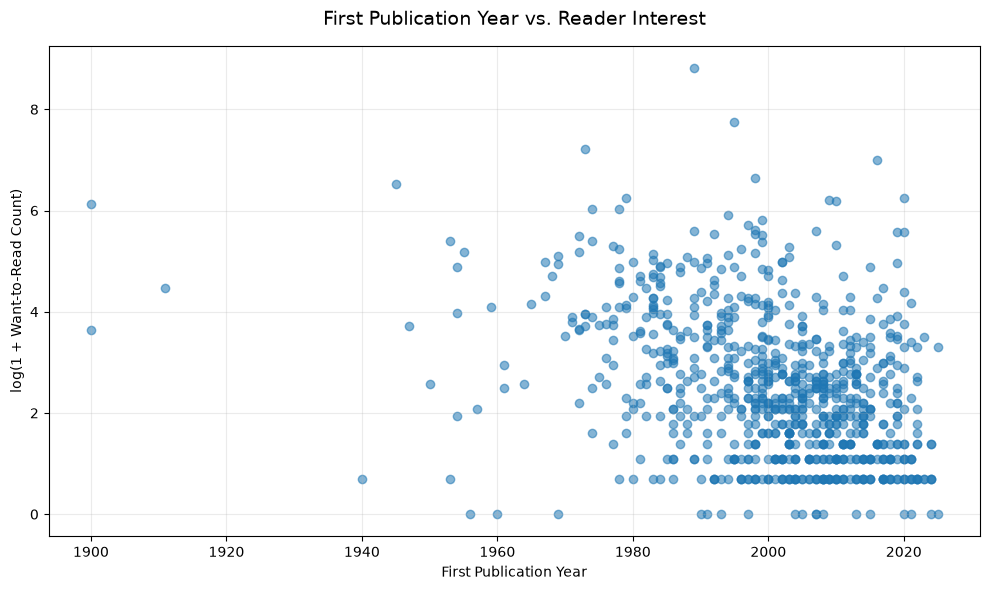

In [19]:
# ============================================================
# HYPOTHESIS 2
# First Publication Year vs Reader Interest
# ============================================================

h2_data = (
    books[
        [
            "book_id",
            "canonical_title",
            "first_publish_year",
            "want_to_read_count"
        ]
    ]
    .dropna(
        subset=[
            "first_publish_year",
            "want_to_read_count"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Spearman correlation — primary test
# ------------------------------------------------------------

rho_h2, p_h2 = stats.spearmanr(
    h2_data["first_publish_year"],
    h2_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Raw Pearson — descriptive comparison
# ------------------------------------------------------------

pearson_h2, pearson_p_h2 = stats.pearsonr(
    h2_data["first_publish_year"],
    h2_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Log-transformed reader interest
# ------------------------------------------------------------

h2_data["log_want_to_read"] = np.log1p(
    h2_data["want_to_read_count"]
)

log_pearson_h2, log_pearson_p_h2 = stats.pearsonr(
    h2_data["first_publish_year"],
    h2_data["log_want_to_read"]
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

alpha = 0.05

print("HYPOTHESIS 2 RESULTS")
print("=" * 75)

print(f"Paired observations:              {len(h2_data):,}")
print(f"Spearman rho:                     {rho_h2:.4f}")
print(f"Spearman p-value:                 {p_h2:.6f}")

print()

print(f"Raw Pearson r:                    {pearson_h2:.4f}")
print(f"Raw Pearson p-value:              {pearson_p_h2:.6f}")

print()

print(f"Pearson r after log1p interest:   {log_pearson_h2:.4f}")
print(f"Log-transformed Pearson p-value:  {log_pearson_p_h2:.6f}")


print("\nSTATISTICAL DECISION")
print("=" * 75)

if p_h2 < alpha:
    print("Reject H0 at α = 0.05.")
    print(
        "Evidence indicates a statistically significant "
        "monotonic association."
    )
else:
    print("Fail to reject H0 at α = 0.05.")
    print(
        "Insufficient evidence of a statistically significant "
        "monotonic association."
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    h2_data["first_publish_year"],
    h2_data["log_want_to_read"],
    alpha=0.55
)

ax.set_title(
    "First Publication Year vs. Reader Interest",
    fontsize=14,
    pad=15
)

ax.set_xlabel("First Publication Year")
ax.set_ylabel("log(1 + Want-to-Read Count)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Hypothesis 2 Interpretation

The Spearman rank-order correlation identified a statistically significant negative association between first publication year and reader interest (`ρ = -0.3741`, `p < 0.001`) across 805 books.

The null hypothesis is therefore **rejected at α = 0.05**.

The negative coefficient indicates that books with earlier first-publication years tend to have higher `want_to_read_count` values in the observed sample. The magnitude of the Spearman coefficient indicates a moderate monotonic association.

The raw Pearson correlation was considerably smaller (`r = -0.1095`, `p = 0.001855`). However, after applying a `log1p()` transformation to the highly skewed reader-interest variable, the Pearson correlation increased in magnitude to `r = -0.3657` (`p < 0.001`), closely aligning with the Spearman result.

The consistency between the Spearman correlation and the log-transformed Pearson correlation strengthens the evidence that the relationship is not solely an artifact of a few extreme `want_to_read_count` observations.

### Practical and Recommendation-System Implication

Within the observed data, older established works tend to exhibit greater reader interest than more recently first-published works.

This relationship should not be interpreted causally. Older books may have had more time to accumulate recognition or reader interest, and the pattern may also reflect source-selection, catalogue-composition, or survivorship effects.

For recommendation modelling, publication recency and reader interest should therefore remain separate features. A recommendation algorithm should not automatically favor newer books under the assumption that newer publications are more popular.

The finding also supports retaining historically established works alongside recent publications so that the recommendation system can distinguish **recency** from **observed reader interest**.

## 4. Hypothesis 3 — Edition Count and Reader Interest

### Research Question

Is the number of recorded editions associated with reader interest as measured by `want_to_read_count`?

### Hypotheses

**H₀ (Null Hypothesis):**  
There is no monotonic association between `edition_count` and `want_to_read_count`.

**H₁ (Alternative Hypothesis):**  
There is a monotonic association between `edition_count` and `want_to_read_count`.

### Statistical Test

A **Spearman rank-order correlation** is used as the primary test because both edition count and reader-interest count are positively skewed count variables.

The analysis includes books for which both variables are available. Statistical significance is evaluated at **α = 0.05**.

HYPOTHESIS 3 RESULTS
Paired observations:                 807
Spearman rho:                        0.4243
Spearman p-value:                    1.35278e-36

Raw Pearson r:                       0.3867
Raw Pearson p-value:                 3.5669e-30

Pearson r after log1p both variables:  0.4705
Log-transformed Pearson p-value:     1.08345e-45

STATISTICAL DECISION
Reject H0 at α = 0.05.
Evidence indicates a statistically significant monotonic association.


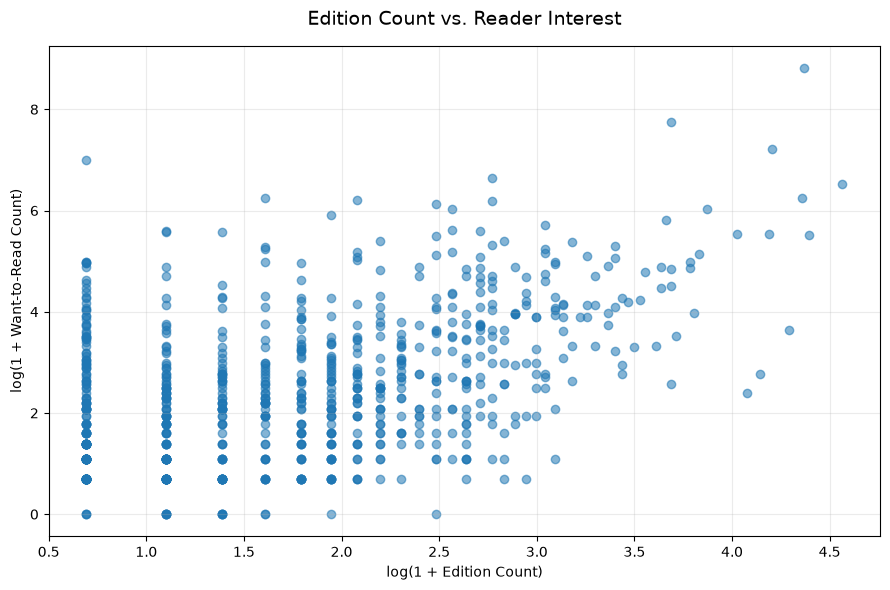

In [20]:
# ============================================================
# HYPOTHESIS 3
# Edition Count vs Reader Interest
# ============================================================

h3_data = (
    books[
        [
            "book_id",
            "canonical_title",
            "edition_count",
            "want_to_read_count"
        ]
    ]
    .dropna(
        subset=[
            "edition_count",
            "want_to_read_count"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Spearman correlation — primary test
# ------------------------------------------------------------

rho_h3, p_h3 = stats.spearmanr(
    h3_data["edition_count"],
    h3_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Raw Pearson — descriptive comparison
# ------------------------------------------------------------

pearson_h3, pearson_p_h3 = stats.pearsonr(
    h3_data["edition_count"],
    h3_data["want_to_read_count"]
)


# ------------------------------------------------------------
# Log transformations
# ------------------------------------------------------------

h3_data["log_edition_count"] = np.log1p(
    h3_data["edition_count"]
)

h3_data["log_want_to_read"] = np.log1p(
    h3_data["want_to_read_count"]
)


log_pearson_h3, log_pearson_p_h3 = stats.pearsonr(
    h3_data["log_edition_count"],
    h3_data["log_want_to_read"]
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

alpha = 0.05

print("HYPOTHESIS 3 RESULTS")
print("=" * 75)

print(f"Paired observations:                 {len(h3_data):,}")
print(f"Spearman rho:                        {rho_h3:.4f}")
print(f"Spearman p-value:                    {p_h3:.6g}")

print()

print(f"Raw Pearson r:                       {pearson_h3:.4f}")
print(f"Raw Pearson p-value:                 {pearson_p_h3:.6g}")

print()

print(f"Pearson r after log1p both variables:{log_pearson_h3:>8.4f}")
print(f"Log-transformed Pearson p-value:     {log_pearson_p_h3:.6g}")


print("\nSTATISTICAL DECISION")
print("=" * 75)

if p_h3 < alpha:
    print("Reject H0 at α = 0.05.")
    print(
        "Evidence indicates a statistically significant "
        "monotonic association."
    )
else:
    print("Fail to reject H0 at α = 0.05.")
    print(
        "Insufficient evidence of a statistically significant "
        "monotonic association."
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    h3_data["log_edition_count"],
    h3_data["log_want_to_read"],
    alpha=0.55
)

ax.set_title(
    "Edition Count vs. Reader Interest",
    fontsize=14,
    pad=15
)

ax.set_xlabel("log(1 + Edition Count)")
ax.set_ylabel("log(1 + Want-to-Read Count)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Hypothesis 3 Interpretation

The Spearman rank-order correlation identified a statistically significant positive association between edition count and reader interest (`ρ = 0.4243`, `p < 0.001`) across 807 books.

The null hypothesis is therefore **rejected at α = 0.05**.

The positive coefficient indicates that books with a greater number of recorded editions tend to have higher `want_to_read_count` values. The magnitude of the Spearman coefficient represents a moderate monotonic association.

The raw Pearson correlation produced a similar positive relationship (`r = 0.3867`, `p < 0.001`). After applying `log1p()` transformations to both edition count and reader interest, the Pearson correlation increased to `r = 0.4705` (`p < 0.001`).

The consistency of the direction and statistical significance across Spearman, raw Pearson, and log-transformed Pearson analyses provides evidence that the observed positive relationship is not dependent on a single statistical specification.

### Practical and Recommendation-System Implication

Books represented by more editions tend to exhibit greater reader interest in the observed dataset. Edition count may therefore contain useful information related to the broader visibility, longevity, or bibliographic presence of a book.

However, the relationship should not be interpreted causally. A larger edition count does not necessarily cause greater reader interest. Established or widely distributed books may simultaneously accumulate both additional editions and greater reader attention.

For recommendation modelling, `edition_count` may therefore be useful as a supplementary feature. However, because it is moderately associated with reader interest, the two variables should not automatically be treated as completely independent indicators of popularity. Their contribution should be evaluated during feature engineering and model development.

## 5. Hypothesis 4 — Page Count by Edition Format

### Research Question

Does page count differ between hardcover and paperback editions in the LeadershipNow dataset?

### Hypotheses

**H₀ (Null Hypothesis):**  
The distribution of page counts does not differ between hardcover and paperback editions.

**H₁ (Alternative Hypothesis):**  
The distribution of page counts differs between hardcover and paperback editions.

### Statistical Test

A two-sided **Mann–Whitney U test** is used because page count is positively skewed and the two edition-format groups are independent.

The test evaluates differences in the distributions of page counts without requiring the normality assumption of an independent-samples t-test.

Statistical significance is evaluated at **α = 0.05**.

GROUP DESCRIPTIVE STATISTICS
Hardcover: n=923, median=272.0, mean=288.7
Paperback: n=196, median=224.0, mean=230.9

HYPOTHESIS 4 RESULTS
Mann-Whitney U:             130,513.0
p-value:                    1.51055e-22
Rank-biserial correlation:  0.4429

STATISTICAL DECISION
Reject H0 at α = 0.05.
Evidence indicates a statistically significant difference in page-count distributions.


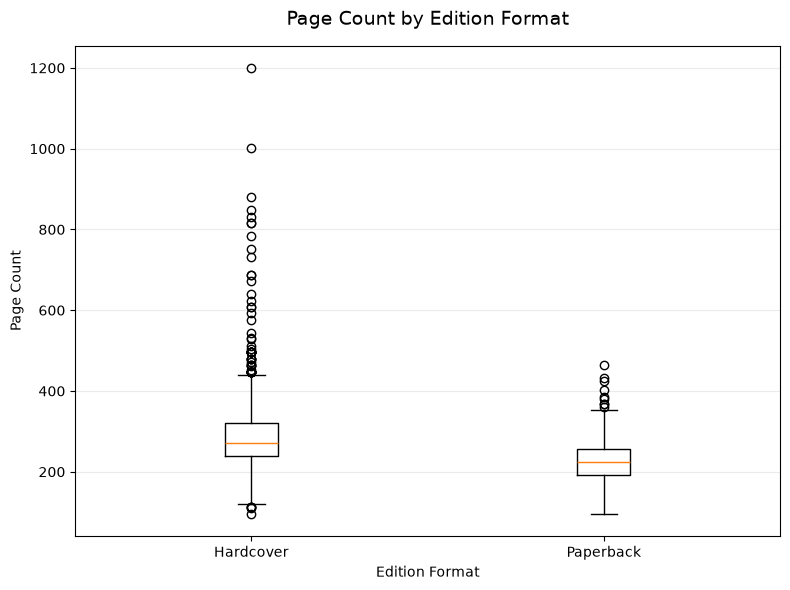

In [21]:
# ============================================================
# HYPOTHESIS 4
# Page Count: Hardcover vs Paperback
# ============================================================

h4_data = (
    editions[
        [
            "book_id",
            "format",
            "page_count"
        ]
    ]
    .dropna(subset=["format", "page_count"])
    .copy()
)

h4_data["format"] = h4_data["format"].astype(str).str.strip()


# ------------------------------------------------------------
# Extract groups
# ------------------------------------------------------------

hardcover = h4_data.loc[
    h4_data["format"].str.lower() == "hardcover",
    "page_count"
]

paperback = h4_data.loc[
    h4_data["format"].str.lower() == "paperback",
    "page_count"
]


# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------

print("GROUP DESCRIPTIVE STATISTICS")
print("=" * 75)

print(
    f"Hardcover: n={len(hardcover):,}, "
    f"median={hardcover.median():.1f}, "
    f"mean={hardcover.mean():.1f}"
)

print(
    f"Paperback: n={len(paperback):,}, "
    f"median={paperback.median():.1f}, "
    f"mean={paperback.mean():.1f}"
)


# ------------------------------------------------------------
# Mann-Whitney U test
# ------------------------------------------------------------

u_stat, p_h4 = stats.mannwhitneyu(
    hardcover,
    paperback,
    alternative="two-sided"
)


# ------------------------------------------------------------
# Rank-biserial effect size
#
# Positive value here means hardcover observations tend
# to have larger page counts than paperback observations.
# ------------------------------------------------------------

n_h = len(hardcover)
n_p = len(paperback)

rank_biserial = (
    (2 * u_stat) / (n_h * n_p)
) - 1


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

alpha = 0.05

print("\nHYPOTHESIS 4 RESULTS")
print("=" * 75)

print(f"Mann-Whitney U:             {u_stat:,.1f}")
print(f"p-value:                    {p_h4:.6g}")
print(f"Rank-biserial correlation:  {rank_biserial:.4f}")


print("\nSTATISTICAL DECISION")
print("=" * 75)

if p_h4 < alpha:
    print("Reject H0 at α = 0.05.")
    print(
        "Evidence indicates a statistically significant "
        "difference in page-count distributions."
    )
else:
    print("Fail to reject H0 at α = 0.05.")
    print(
        "Insufficient evidence of a statistically significant "
        "difference in page-count distributions."
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plot_data = [
    hardcover.values,
    paperback.values
]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    plot_data,
    tick_labels=["Hardcover", "Paperback"],
    showfliers=True
)

ax.set_title(
    "Page Count by Edition Format",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Edition Format")
ax.set_ylabel("Page Count")

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Hypothesis 4 Interpretation

The Mann–Whitney U test identified a statistically significant difference in page-count distributions between hardcover and paperback editions (`U = 130,513`, `p < 0.001`).

The null hypothesis is therefore **rejected at α = 0.05**.

Hardcover editions had a median page count of **272 pages** (`n = 923`), compared with **224 pages** for paperback editions (`n = 196`). Mean page counts showed the same direction, with approximately **288.7 pages** for hardcover editions and **230.9 pages** for paperback editions.

The rank-biserial correlation was **0.4429**, indicating a meaningful positive effect in the direction of higher page counts among hardcover editions.

### Practical and Recommendation-System Implication

Within the LeadershipNow edition data, hardcover editions tend to contain more pages than paperback editions. This indicates that edition format and page count are related characteristics rather than completely independent attributes.

For the recommendation system, page count may provide information about book length or reading commitment, while format describes the observed physical edition. These variables should remain conceptually distinct, but their relationship should be considered during feature engineering.

The result applies specifically to the observed LeadershipNow edition records and should not be generalized to all published books without additional evidence.

In [22]:
# ============================================================
# CONSOLIDATED HYPOTHESIS TEST RESULTS
# ============================================================

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "H1",
        "H2",
        "H3",
        "H4"
    ],

    "Research Question": [
        "Average rating vs reader interest",
        "First publication year vs reader interest",
        "Edition count vs reader interest",
        "Page count: Hardcover vs Paperback"
    ],

    "Primary Test": [
        "Spearman correlation",
        "Spearman correlation",
        "Spearman correlation",
        "Mann-Whitney U"
    ],

    "Sample Size": [
        282,
        805,
        807,
        1119
    ],

    "Statistic": [
        rho,
        rho_h2,
        rho_h3,
        u_stat
    ],

    "Effect Size": [
        rho,
        rho_h2,
        rho_h3,
        rank_biserial
    ],

    "p_value": [
        p_value,
        p_h2,
        p_h3,
        p_h4
    ]
})


hypothesis_results["Decision"] = np.where(
    hypothesis_results["p_value"] < 0.05,
    "Reject H0",
    "Fail to reject H0"
)


display(
    hypothesis_results.style.format({
        "Statistic": "{:,.4f}",
        "Effect Size": "{:.4f}",
        "p_value": "{:.3e}"
    })
)

,Hypothesis,Research Question,Primary Test,Sample Size,Statistic,Effect Size,p_value,Decision
0,H1,Average rating vs reader interest,Spearman correlation,282,-0.0781,-0.0781,1.912e-01,Fail to reject H0
1,H2,First publication year vs reader interest,Spearman correlation,805,-0.3741,-0.3741,3.866e-28,Reject H0
2,H3,Edition count vs reader interest,Spearman correlation,807,0.4243,0.4243,1.353e-36,Reject H0
3,H4,Page count: Hardcover vs Paperback,Mann-Whitney U,1119,"130,513.0000",0.4429,1.511e-22,Reject H0


In [23]:
# ============================================================
# MULTIPLE-TESTING SENSITIVITY CHECK
# ============================================================

number_of_tests = 4
alpha = 0.05

bonferroni_alpha = alpha / number_of_tests

hypothesis_results["Significant_at_0.05"] = (
    hypothesis_results["p_value"] < alpha
)

hypothesis_results["Significant_Bonferroni"] = (
    hypothesis_results["p_value"] < bonferroni_alpha
)


print("MULTIPLE-TESTING SENSITIVITY CHECK")
print("=" * 70)

print(f"Original alpha:       {alpha:.4f}")
print(f"Number of tests:      {number_of_tests}")
print(f"Bonferroni alpha:     {bonferroni_alpha:.4f}")

print()

display(
    hypothesis_results[
        [
            "Hypothesis",
            "p_value",
            "Significant_at_0.05",
            "Significant_Bonferroni"
        ]
    ].style.format({
        "p_value": "{:.3e}"
    })
)

MULTIPLE-TESTING SENSITIVITY CHECK
Original alpha:       0.0500
Number of tests:      4
Bonferroni alpha:     0.0125



,Hypothesis,p_value,Significant_at_0.05,Significant_Bonferroni
0,H1,1.912e-01,False,False
1,H2,3.866e-28,True,True
2,H3,1.353e-36,True,True
3,H4,1.511e-22,True,True


# 6. Statistical Conclusions and Model Readiness

## 6.1 Summary of Hypothesis Tests

Four inferential analyses were conducted to examine relationships relevant to reader interest, bibliographic characteristics, and the future recommendation system.

### H1 — Average Rating and Reader Interest

The relationship between average rating and `want_to_read_count` was not statistically significant under the primary Spearman rank-order test (`ρ = -0.0781`, `p = 0.1912`, `n = 282`).

Therefore, the null hypothesis was **not rejected**.

This finding indicates that average rating and reader interest represent different dimensions within the observed data. Highly rated books are not necessarily the books generating the greatest reader interest.

A supplementary Pearson analysis using log-transformed reader interest produced a weak positive relationship, but this did not replace the pre-specified non-parametric result.

---

### H2 — First Publication Year and Reader Interest

A statistically significant moderate negative association was identified between first publication year and reader interest (`ρ = -0.3741`, `p < 0.001`, `n = 805`).

The null hypothesis was therefore **rejected**.

Earlier first-publication years tended to be associated with higher `want_to_read_count` values. This may reflect accumulated recognition, longevity, catalogue-selection effects, or survivorship rather than a causal effect of book age.

Publication year and reader interest should consequently remain separate features in the recommendation system.

---

### H3 — Edition Count and Reader Interest

Edition count demonstrated a statistically significant moderate positive association with reader interest (`ρ = 0.4243`, `p < 0.001`, `n = 807`).

The null hypothesis was therefore **rejected**.

Books represented by more editions tended to have higher `want_to_read_count` values. Edition count may therefore contain useful information related to bibliographic presence, longevity, visibility, or popularity.

However, edition count and reader interest contain partially overlapping information and should not automatically be treated as completely independent popularity indicators.

---

### H4 — Page Count and Edition Format

Page-count distributions differed significantly between hardcover and paperback editions (`U = 130,513`, `p < 0.001`, `n = 1,119`).

Hardcover editions had a median length of **272 pages**, compared with **224 pages** for paperback editions.

The rank-biserial correlation of **0.4429** indicates a meaningful difference in the observed page-count distributions, with hardcover editions tending to have higher page counts.

Page count and edition format therefore represent related but conceptually distinct bibliographic characteristics.

---

## 6.2 Multiple-Testing Sensitivity

Because four primary hypothesis tests were conducted, a Bonferroni sensitivity check was applied.

The conventional significance threshold was:

**α = 0.05**

The Bonferroni-adjusted threshold was:

**α = 0.05 / 4 = 0.0125**

The conclusions remained unchanged:

- H1 remained non-significant.
- H2 remained statistically significant.
- H3 remained statistically significant.
- H4 remained statistically significant.

The principal inferential findings are therefore robust to this conservative multiple-testing adjustment.

---

## 6.3 Statistical and Business Interpretation

The statistical analysis demonstrates that different bibliographic and engagement variables capture different aspects of a book's observed characteristics.

Most importantly, **rating should not be treated as equivalent to reader interest**. The absence of a significant monotonic relationship between average rating and `want_to_read_count` suggests that evaluation and popularity should remain separate dimensions.

Publication history also matters. Earlier published books tended to exhibit greater reader interest, while books represented by more editions also tended to attract greater interest. These patterns suggest that longevity and bibliographic presence may contribute useful contextual information to recommendation modelling.

The analysis further demonstrates that physical-edition characteristics are related. Hardcover editions tended to have greater page counts than paperback editions, indicating that format and length should not automatically be treated as independent characteristics.

---

## 6.4 Implications for Feature Engineering

The statistical results support retaining several distinct feature families for subsequent modelling:

1. **Content features**
   - title
   - authors
   - subjects
   - description

2. **Temporal features**
   - first publication year
   - observed publication year
   - derived book age or recency

3. **Reader-engagement features**
   - want-to-read count
   - currently-reading count
   - already-read count

4. **Rating features**
   - average rating
   - rating count

5. **Bibliographic features**
   - edition count
   - page count
   - format
   - publisher

Highly skewed count variables should retain their original values while also being considered for `log1p()` transformation during feature engineering.

The statistical results do not justify removing extreme observations solely because they are large. These observations may represent legitimately prominent books and should instead be handled through appropriate transformation and robust modelling techniques.

---

## 6.5 Recommendation-System Implications

The findings support a **multi-dimensional content-oriented recommendation architecture** rather than a system based solely on ratings or popularity.

The core recommendation representation should primarily use broadly available content information such as:

- title
- authors
- subjects
- description

Reader-engagement, rating, temporal, and bibliographic variables may subsequently provide supplementary signals where available.

This distinction is important because metadata coverage is uneven across the catalogue. Ratings are available for only a limited subset of books, whereas titles and authors have substantially greater coverage.

A recommendation system dependent exclusively on ratings would therefore exclude a large proportion of the catalogue.

---

## 6.6 Limitations

Several limitations should be considered when interpreting the statistical results.

First, missingness is strongly related to data source. Ratings, reader-engagement measures, edition information, and other metadata are not uniformly available across all 2,067 books.

Second, the analyses identify **associations rather than causal relationships**. For example, the relationship between edition count and reader interest does not demonstrate that publishing additional editions causes greater reader interest.

Third, reader-engagement and rating measures reflect the available source data and should not be interpreted as universal measures of book quality or global popularity.

Fourth, the dataset combines complementary sources with different metadata structures and coverage. Statistical conclusions therefore apply to the observed samples used in each analysis rather than automatically generalizing to all leadership and management books.

Finally, the analysis intentionally avoids imputing unavailable ratings, engagement values, descriptions, or other substantive metadata because doing so could introduce artificial statistical relationships.

---

## 6.7 Final Statistical Assessment

The statistical analysis provides sufficient evidence to proceed to feature engineering.

The principal findings are:

- average rating is not a reliable proxy for reader interest
- earlier first-publication years are moderately associated with greater observed reader interest
- edition count is moderately associated with greater reader interest
- hardcover editions tend to have higher page counts than paperback editions
- major statistical conclusions remain unchanged after Bonferroni adjustment
- highly skewed numerical variables require appropriate transformation rather than automatic outlier removal
- content, popularity, rating, temporal, and bibliographic features should remain conceptually distinct

These findings provide an empirical basis for constructing the feature set used in subsequent NLP, dimensionality-reduction, clustering, and recommendation-system modelling.